In [2]:
from openai import OpenAI
import os
import chromadb
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction
from dotenv import load_dotenv, find_dotenv
import gradio as gr
import umap
from sklearn.cluster import KMeans
import plotly.express as px
import pandas as pd

C:\Users\clair\OneDrive\Documents\LLM\project4-students\proj4_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# get .env file  
load_dotenv(find_dotenv(usecwd=True))  
    
# load open ai api key and create client
api_key = os.getenv("OPENAI_API_KEY") 
if not api_key: 
    print("Warning: OPENAI_API_KEY not found in environment") 
    ai_client = None 
else: 
    ai_client = OpenAI(api_key=api_key, base_url="https://openrouter.ai/api/v1") 
    print("OpenRouter client created successfully!") 

OpenRouter client created successfully!


In [4]:
# CONFIG 
CHUNK_SIZE    = 4200  # Maximum characters per chunk, a short paragraph is typically around 300-500 characters
CHUNK_OVERLAP = 100    # Overlap between consecutive chunks
TOP_K         = 3     # Number of chunks to retrieve per query
LLM_MODEL     = "gpt-4o-mini"
 
SYSTEM_PROMPT = (
    "You are a helpful assistant that answers questions about paddleboard and kayak "
    "laws and common practices. You also give suggestions of where to go based on desires."
    "Answer using only the provided context. If the answer is not in the context, say so clearly.")

In [5]:
def chunk(text: str, splits: dict, overlap: int) -> list[str]: 
    chunks = []
    
    for i in range(len(splits)+1):   # for i in range 1+ length bc splits are indexes to split on
        if i==0: chunk = text[:splits[i]+overlap]    # for first chunk use first split 
            
        elif i==len(splits): chunk = text[splits[i-1]-overlap:]
            
        else: chunk = text[splits[i-1]-overlap : splits[i]+overlap]
    
        chunks.append(chunk)

    return chunks


In [6]:
def load_and_chunk(chunk_splits: dict, overlap: int) -> tuple[list[str], list[dict], list[str]]:
    """
    Load every .txt file from docs_dir and split into overlapping chunks.
    """
    all_chunks = []
    metadata = []
    ids = []

    for doc in chunk_splits:
        with open("Cleaned Txt Files/" + doc, "r", encoding="utf-8") as f:  # open doc and read into text variable 
            text = f.read()    
            
        if chunk_splits[doc] == None:   # doc split is None if only one chunk 
            all_chunks.append(text) 
            metadata.append({"document_title": doc, "chunk_number": 0})
            ids.append(doc + '_0')
            
        else: 
            chunk_holder = chunk(text, chunk_splits[doc], overlap)

            counter = 0 
            for i in chunk_holder: 
                all_chunks.append(i)
                metadata.append({"document_title": doc, "chunk_number": counter})
                ids.append(doc + '_' + str(counter))
                counter+=1
        
    return (all_chunks, metadata, ids)


In [7]:
def index_chunks(chunks: list[str], metadata: list[dict], ids: list[str]) -> chromadb.Collection:
    """
    Add only new chunks to ChromaDB. Existing chunk IDs are skipped, so rerunning the notebook does not
    overwrite existing chunks or recompute embeddings for them.
    """
    # create chroma DB
    chroma_client = chromadb.PersistentClient(path='.chroma_persistent_db') 
    
    # create embedding function
    openai_ef = OpenAIEmbeddingFunction( 
                    api_key=ai_client.api_key, 
                    model_name="text-embedding-3-small", 
                    dimensions=512)
    
    # See if the collection exists, and if it doesn't then create it 
    try: 
        collection = chroma_client.get_collection(name="paddlecraft_docs", embedding_function = openai_ef) 
    except: 
        collection = chroma_client.create_collection(name="paddlecraft_docs", embedding_function=openai_ef) 
    
    # load the data into it
    collection.add(ids=ids, documents=chunks, metadatas=metadata)
    
    return collection


In [8]:
def retrieve(collection: chromadb.Collection, query: str, top_k: int) -> dict[list]:
    """
    Return the top_k most semantically similar chunks for a given query.
     """
    results = collection.query(query_texts=[query], n_results=top_k)
    
    return results
    

In [9]:
def build_prompt(query: str, context_chunks: list[dict], history:list[str]) -> str:
    """
    Assemble the prompt sent to the Responses API.
 
    Structure:
        [Retrieved context chunks]
        [User question]
 
    The system instruction is passed separately via `instructions` in
    generate_answer(), keeping system and user content clearly separated.
    """
    context_intro = 'Here is some context on paddeboarding and kayaking: \n'
    context = '\n\n'.join(context_chunks['documents'][0])
    history_intro = '\nHere is some past chat history that may provide more context: \n'
    chat_history = '\n'.join([f"{i['role']}: {i['content']}" for i in history])
    query_intro = '\nNow using that context respond to the following: \n'
    context_ids = context_chunks['ids'][0]

    if history == None: prompt = context_intro + context + query_intro + query
    else: prompt = context_intro + context + history_intro + chat_history + query_intro + query
    
    return prompt, context_ids

In [10]:
def generate_answer(client: OpenAI, prompt: str) -> str:
    """
    Send the prompt to the OpenAI Responses API and return the reply.
    """
    response = client.responses.create(
        model=LLM_MODEL,
        instructions=SYSTEM_PROMPT,
        input=prompt,
        temperature=0.0,
        max_output_tokens=512,)
    
    return response.output_text.strip()

In [11]:
def build_ui(collection: chromadb.Collection, llm_client: OpenAI) -> gr.ChatInterface:
    """
    Construct and return the Gradio ChatInterface.
    """
    def chat(message: str, history: list[dict]) -> str:
        context = retrieve(collection, message, TOP_K)
        prompt, context_ids = build_prompt(message, context, history)
        answer = generate_answer(llm_client, prompt)
        return (answer + '\nSources:' + ', '.join(context_ids))
        
    return gr.ChatInterface(fn=chat, 
                            title="Colorado Paddleboard and Kayak Virtual Assistant",
                            chatbot=gr.Chatbot(height=460))

In [12]:
def embedding_3d_visual(query):
    all_data = collection.get(include=["documents", "metadatas", "embeddings"])
    
    embeddings = all_data['embeddings']
    coords = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(embeddings)
    
    chunks = all_data['documents']
    chunk_preview = [i[:50] for i in chunks]
    
    results = collection.query(query_texts=[query], n_results=29, include=["distances"])
    distances = results["distances"][0]
    
    documents = [i['document_title'] for i in all_data['metadatas']]
    
    plot_df = pd.DataFrame({'Dimension 1': coords.T[0], 'Dimension 2': coords.T[1], 'Dimension 3': coords.T[0], 
                            'Document Name': documents, 'Chunk Preview': chunk_preview, 'Distance From Query': distances})

    fig = px.scatter_3d(plot_df, x='Dimension 1', y='Dimension 2', z='Dimension 3',
                        color='Distance From Query', hover_data=['Document Name', 'Chunk Preview'], 
                        title=f'Distance of Chunk Embeddings From Query Embedding ({query})')
    fig.show()
    return 

In [13]:
def main() -> chromadb.Collection:
    chunk_splits = {
    'Colorado_Boating_Handbook.txt': [1650, 3500, 5690, 7505, 10899, 12313, 13995, 16654, 20699, 24291, 25535, 28930, 31067, 35251, 38189],
    'Colorado_Kayaking_Laws.txt': [2430, 4014, 5585, 7060],
    'Colorado_Paddleboard_Laws.txt': None,
    'Safety_Checklist.txt': None, 
    'Colorado_Paddleboard_Guide.txt': [1370, 4099, 6091],
    'Best_Paddleboarding_Colorado.txt': [2694]}
    
    chunks, metadata, ids = load_and_chunk(chunk_splits, 100)

    collection = index_chunks(chunks, metadata, ids)
    
    return collection 

collection = main()

C:\Users\clair\OneDrive\Documents\LLM\project4-students\proj4_venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


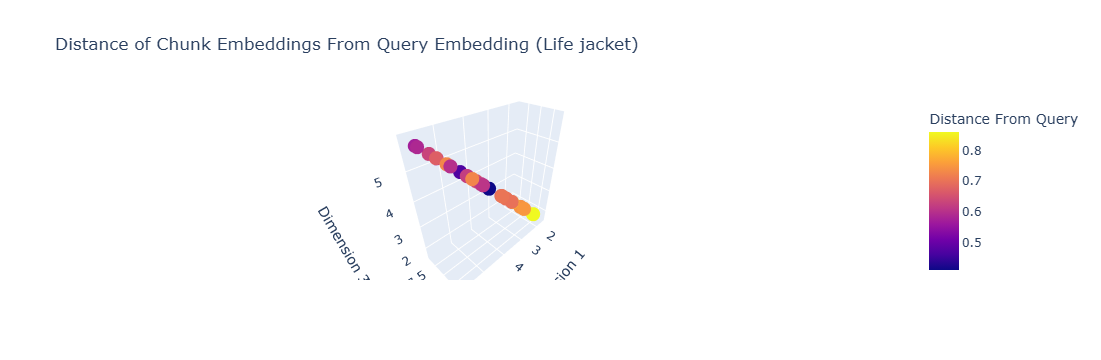

In [14]:
# 3D Visulaization
embedding_3d_visual('Life jacket')

In [15]:
# Gradio Interface 
llm_client = OpenAI(api_key=api_key)
build_ui(collection, llm_client).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d656bfba983085cc7d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
